<a href="https://colab.research.google.com/github/IanWills03/Programming-for-Data-Analysis-CMet/blob/main/Programming_for_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Programming for Data Analysis Submission**




[Github Repository](https://github.com/IanWills03/Programming-for-Data-Analysis-CMet/blob/main/Programming_for_Data_Analysis.ipynb)

# Task 1: Data Selection and Handling

This section involved choosing two urban and two suburban locations, accesing them thorugh Github repositories and then merging them into one dataset for future processing.

**Justification for Location Selection**

Huairou and Dingling were selected for the suburban locations as Huariou was the further station from central Beijing, which would potentially lead to a wider variety of air quality conditions as there would be less impact from urban emissions. In contrast, Dingling was closer to the city, allowing for analysis of how pollution levels change depending on how close in proximity the location is to urban sources.

Gucheng and Dongsi were selected as the urban stations to investigate how other factors, such as wind speed and direction effected pollution levels through a range of atmospheric conditions.

In [1]:
!pip install streamlit
!pip install --upgrade Streamlit
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 42.8 MB/s eta 0:00:00


This part establishes a connection between google colab and the main branch in my github repository

In [2]:
! git config --global user.name "IanWills03"
! git config --global user.email "ianwills003@gmail.com"
username = "IanWills03"
repo = "Programming-for-Data-Analysis-CMet"
! git clone https://github.com/{username}/{repo}

Cloning into 'Programming-for-Data-Analysis-CMet'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 46 (delta 17), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 4.88 MiB | 5.42 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [3]:
import os
%cd /content/Programming-for-Data-Analysis-CMet

/content/Programming-for-Data-Analysis-CMet


This part merges the four csv files into one csv file

In [4]:
beijing_air_files = glob.glob("*.csv")
all_cities_data = []

for file_name in beijing_air_files:
  city_df = pd.read_csv(file_name)
  all_cities_data.append(city_df)
  print(f"Loaded: {file_name}")

combined_data = pd.concat(all_cities_data, ignore_index=True)
combined_data.to_csv("combined_air_pollution_dataset.csv")

print(f"SUCCESS: Combined {len(beijing_air_files)} city files into one file with {len(combined_data)} total rows")
print("The combined file is saved as: combined_air_pollution_dataset.csv")


Loaded: PRSA_Data_Gucheng_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv
Loaded: PRSA_Data_Dingling_20130301-20170228.csv
Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
SUCCESS: Combined 4 city files into one file with 140256 total rows
The combined file is saved as: combined_air_pollution_dataset.csv


# Task 2: Exploratory Data Analysis (EDA)

This section involved analysing the newly aquired merged dataset, then carrying out preprocessing procedures to handle factors such as missing values and duplicate entries, while exploring feature engineering techniques such as datetime components and AQI levels. Finally, the data was then visualised through Univariate, Bivariate and Multivariate relationships using a combination of charts, graphs and heatmaps.

**Task 2.1: Data Understanding**

The dataset includes both air pollutant variables (PM2.5, PM10, SO2, NO2, CO, O3) and meteorological variables (temperature, pressure, wind speed, etc.), allowing analysis of environmental factors influencing air quality.

In [5]:
df = pd.read_csv("combined_air_pollution_dataset.csv")
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 19 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  140256 non-null  int64  
 1   No          140256 non-null  int64  
 2   year        140256 non-null  int64  
 3   month       140256 non-null  int64  
 4   day         140256 non-null  int64  
 5   hour        140256 non-null  int64  
 6   PM2.5       137128 non-null  float64
 7   PM10        137889 non-null  float64
 8   SO2         137376 non-null  float64
 9   NO2         135114 non-null  float64
 10  CO          132224 non-null  float64
 11  O3          136498 non-null  float64
 12  TEMP        140081 non-null  float64
 13  PRES        140083 non-null  float64
 14  DEWP        140079 non-null  float64
 15  RAIN        140087 non-null  float64
 16  wd          139577 non-null  object 
 17  WSPM        140108 non-null  float64
 18  station     140256 non-null  object 
dtypes:

,0
Unnamed: 0,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,3128
PM10,2367
SO2,2880
NO2,5142


This next part creates both a table and heatmap of the missing data

In [6]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * mis_val / len(df)

    table = pd.concat([mis_val, mis_val_percent], axis=1)
    table.columns = ['Missing Values', '% of Total Values']

    return table.sort_values('% of Total Values', ascending=False)

missing_values_table(df)

,Missing Values,% of Total Values
CO,8032,5.726671
NO2,5142,3.666153
O3,3758,2.679386
PM2.5,3128,2.230208
SO2,2880,2.053388
PM10,2367,1.687628
wd,679,0.484115
DEWP,177,0.126198
TEMP,175,0.124772
PRES,173,0.123346


This creates a heat map of the missing data

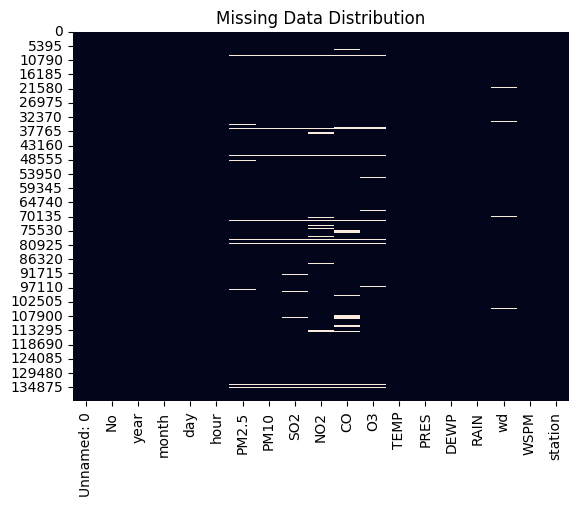

,Unnamed: 0,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.000000,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,137128.000000,137889.000000,137376.000000,135114.000000,132224.000000,136498.000000,140081.00000,140083.000000,140079.000000,140087.000000,140108.000000
mean,70127.500000,17532.500,2014.662560,6.522930,15.729637,11.500000,76.433458,101.156036,14.449835,42.468751,1143.995561,60.793546,13.41694,1009.184718,2.200587,0.064194,1.677524
std,40488.564015,10122.141,1.177201,3.448715,8.800123,6.922211,78.994830,90.945361,20.020561,33.603041,1076.211778,56.080125,11.48208,10.349554,13.873769,0.807661,1.254475
min,0.000000,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.90000,982.400000,-43.400000,0.000000,0.000000
25%,35063.750000,8766.750,2014.000000,4.000000,8.000000,5.750000,19.000000,33.000000,2.000000,16.000000,400.000000,17.000000,3.00000,1000.800000,-9.400000,0.000000,0.900000
50%,70127.500000,17532.500,2015.000000,7.000000,16.000000,11.500000,52.000000,78.000000,6.000000,34.000000,800.000000,51.000000,14.40000,1008.800000,2.600000,0.000000,1.300000
75%,105191.250000,26298.250,2016.000000,10.000000,23.000000,17.250000,107.000000,143.000000,18.000000,61.134550,1400.000000,85.000000,23.10000,1017.300000,15.000000,0.000000,2.100000
max,140255.000000,35064.000,2017.000000,12.000000,31.000000,23.000000,881.000000,994.000000,500.000000,276.000000,10000.000000,1071.000000,41.60000,1042.000000,29.100000,52.100000,12.900000


In [7]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Distribution")
plt.show()
df.describe()


The combination of the table and heatmap showcase the missing values that are present across several pollutant variables such as CO, NO2, and PM2.5. These missing values are scattered rather than concentrated, suggesting they are likely due to temporary sensor failures rather than systematic data loss.

**Task 2.2: Data Preprocessing**

This section of the project was performed to clean and prepare the dataset for future analysis. This involved using both numerical and non-numerical interpolation tehcniques to deal with missing values, removing data duplicates and implementing feature engineering, such as datetime componenets and Air Quality Index levels.

In [8]:
df = pd.read_csv("combined_air_pollution_dataset.csv")

numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols] = df.groupby(["station", "year", "month"])[numeric_cols].transform(
    lambda x: x.interpolate(method="linear")
)

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df["wd"] = df.groupby("station")["wd"].ffill().bfill()

*   Numerical data was imputed using the built in Pandas linear interpolation function, ensuring the values were estimated based on observations from the same station and similar year and month.
*  Non numerical data, particularly the wind direction (wd), interpolation was not applicable. This meant that the forward fill technique was preferred



*   Check to ensure that all missing values have been addressed


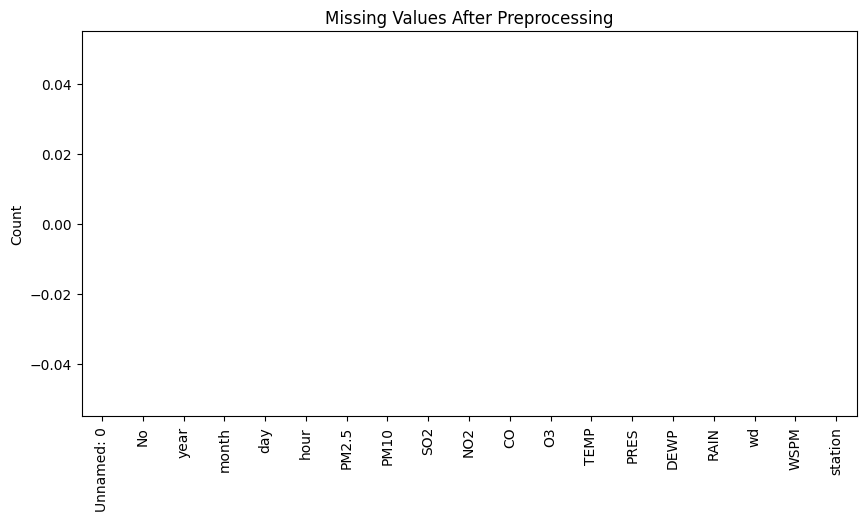

In [9]:
missing = df.isnull().sum()

missing.plot(kind="bar", figsize=(10,5))
plt.title("Missing Values After Preprocessing")
plt.ylabel("Count")
plt.show()

This barchart shows that there are no missing values left in the dataset after data preprocessing, further indicating how successful both interpolaton techniques were.


*   Adding the Datetime Feature Engineering to the dataset
**bold text**






In [10]:
df.drop(columns=["Unnamed: 0"], inplace=True)
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df["month_extracted"] = df["datetime"].dt.month
df["day_of_week"] = df["datetime"].dt.day_name()
df["hour_extracted"] = df["datetime"].dt.hour
print(df[["datetime", "month_extracted", "day_of_week", "hour_extracted"]].head())
print(df.columns)


             datetime  month_extracted day_of_week  hour_extracted
0 2013-03-01 00:00:00                3      Friday               0
1 2013-03-01 01:00:00                3      Friday               1
2 2013-03-01 02:00:00                3      Friday               2
3 2013-03-01 03:00:00                3      Friday               3
4 2013-03-01 04:00:00                3      Friday               4
Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station',
       'datetime', 'month_extracted', 'day_of_week', 'hour_extracted'],
      dtype='object')


The datetime variable was verified to ensure it was correct, with the month, day of the week, and hour all accurately corrsoponding to the original timestamp data. This will be important for the temporal analysis in section 2.3


*   Generating and plotting the Air Quality Index (AQI) levels



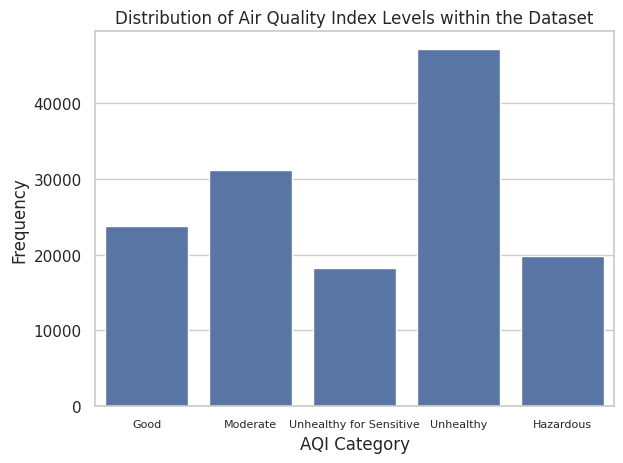

In [11]:
def aqi_level(pm25):
    if pm25 <= 12:
        return "Good"
    elif pm25 <= 35:
        return "Moderate"
    elif pm25 <= 55:
        return "Unhealthy for Sensitive"
    elif pm25 <= 150:
        return "Unhealthy"
    else:
        return "Hazardous"

df["AQI_Level"] = df["PM2.5"].apply(aqi_level)
sns.set(style="whitegrid")
order = ["Good", "Moderate", "Unhealthy for Sensitive", "Unhealthy", "Hazardous"]
sns.countplot(data=df, x="AQI_Level", order=order)

plt.title("Distribution of Air Quality Index Levels within the Dataset", fontsize=12)
plt.xlabel("AQI Category")
plt.ylabel("Frequency")
plt.xticks(fontsize = 8)
plt.tight_layout()
plt.show()

**Task 2.3: Statistical/Computational Analysis & Visualisation**

**2.3.1 Univariate Analysis**

1.   Distribution of PM2.5







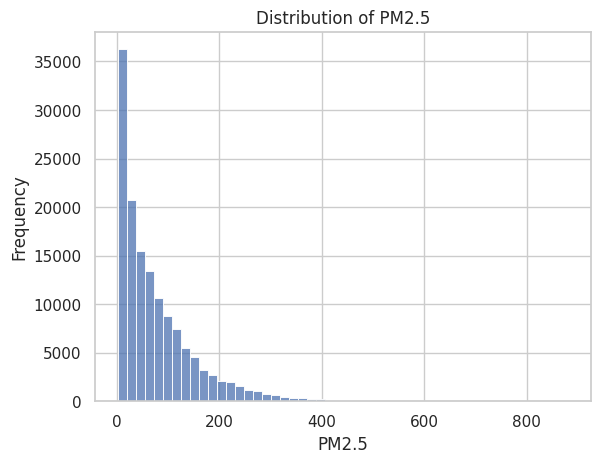

In [12]:
sns.histplot(df["PM2.5"], bins=50)
plt.title("Distribution of PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()

This histogram showcases the concentration of fine particulate matter that has a diameter of less that 2.5 micrometers in the air. The distribution is strongly right-skewed, with the majority of the observations falling within the low-moderate concentration ranges. Finally, there are a small number observations that show extreme pollution levels, suggesting the presence of occasional severe pollution events.



2.   Temperature Distribution

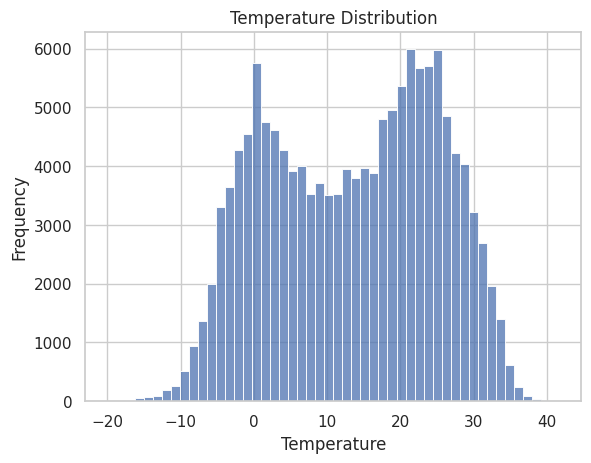

In [13]:
sns.histplot(df["TEMP"], bins=50)
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

This histogram showcases the ranges of temperature values within the dataset. The distribution shows two peaks corrosponding to winter and summer seasons, indicating strong seasonal variation. This in turn is likely to influence pollution behaviour.

3. Wind Direction Frequency

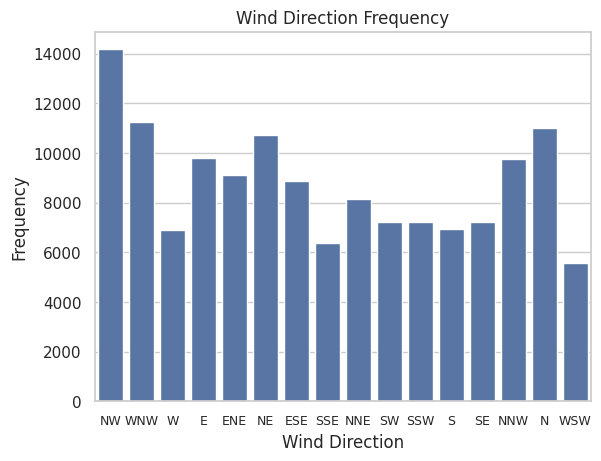

In [14]:
sns.countplot(data=df, x="wd")
plt.title("Wind Direction Frequency")
plt.xlabel("Wind Direction")
plt.ylabel("Frequency")
plt.xticks(fontsize=9)
plt.show()

This histogram illustrates a high variety across all directions, further showcasing why the wind direction could not be disregarded during the data preprocessing stage. If this variable in the dataset was to be removed, it would cause significant bias on the results, nullifying the validity of this study.

**2.3.2 Bivariate Analysis**

1. PM2.5 vs Temperature

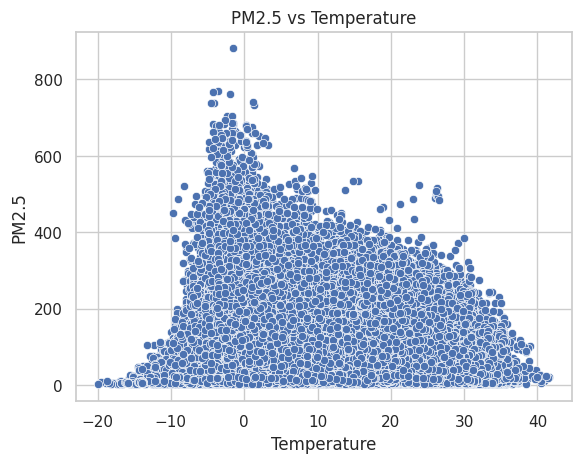

In [15]:
sns.scatterplot(data=df, x="TEMP", y="PM2.5")
plt.title("PM2.5 vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("PM2.5")
plt.show()

This graph illustrates the relationship between temperature and air pollution (PM2.5) levels, with the most severe levels occuring when the temperature is near freezing (around 0°C). From this point, as the temperature is increased or decreased, the pollution levels general tend to drop.

2. NO2 vs O3

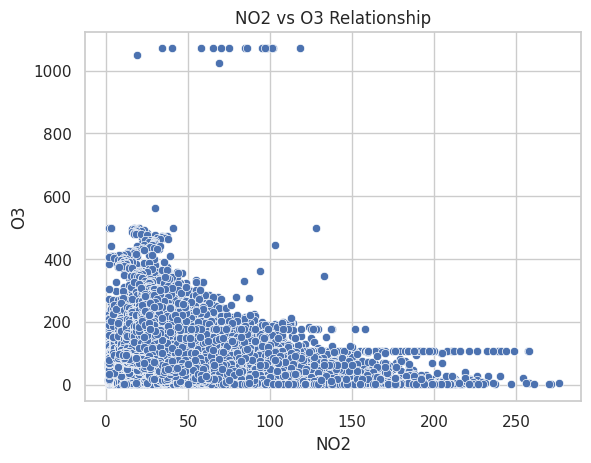

In [16]:
sns.scatterplot(data=df, x="NO2", y="O3")
plt.title("NO2 vs O3 Relationship")
plt.xlabel("NO2")
plt.ylabel("O3")
plt.show()

This scatter plot illustrates a clear inverse relationship between Nitrogen Dioxide (NO2) and ozone gas (O3). As the level of nitrogen dioxide increases, the ozone levels generally decrease, which is a common atmospheric reaction where NO2 acts as a direct precursor to ozone gas.

3. Wind Speed vs PM2.5

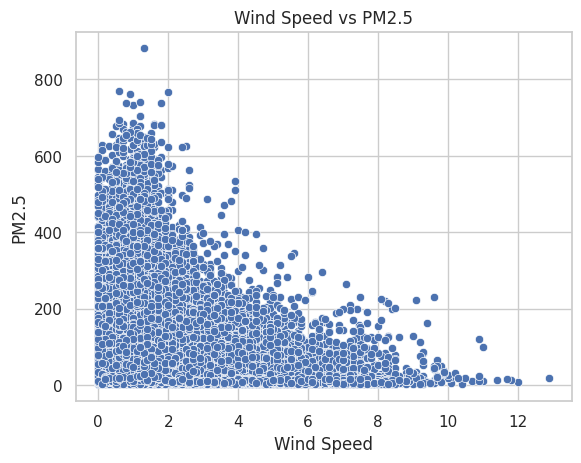

In [17]:
sns.scatterplot(data=df, x="WSPM", y="PM2.5")
plt.title("Wind Speed vs PM2.5")
plt.xlabel("Wind Speed")
plt.ylabel("PM2.5")
plt.show()

This graph illustrates the relationship between wind speed and PM2.5 concentrations. The resulting scatter plot demonstrates that higher wind speeds correlate with lower pollutant, caused by increased atmospheric dispersion. In contrast, lower wind speeds are associated with peak pollution events, as the polluted particles remain trapped near the source of the pollution with nowhere to escape.

**2.3.3 Multivariate Analysis**

1. Correlation Heatmap

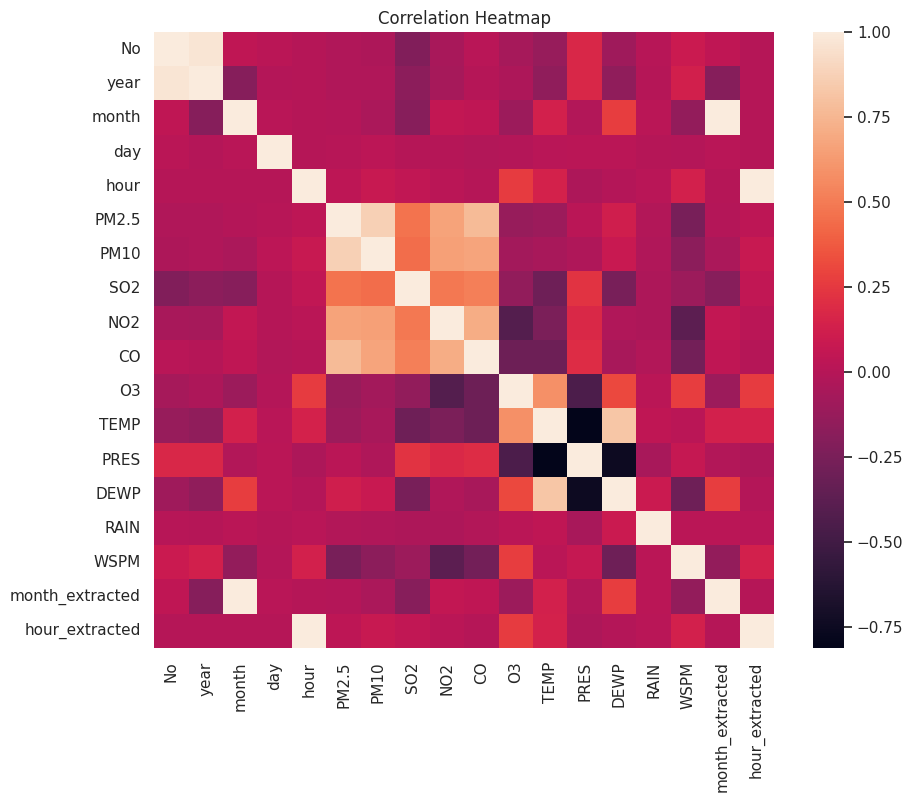

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Correlation Heatmap")
plt.show()

This correlation heatmap provides a multivariate overview of the dataset, showcasing positive associations between pollutants like PM2.5, PM10 and CO, suggesting they likely share common hotspots such as traffic jams or industrial fumes. It also highlights how other factors like pressure and temperature are linked, proving that weather patterns and pollution levels are connected across all 12 stations.

2. Pairplot

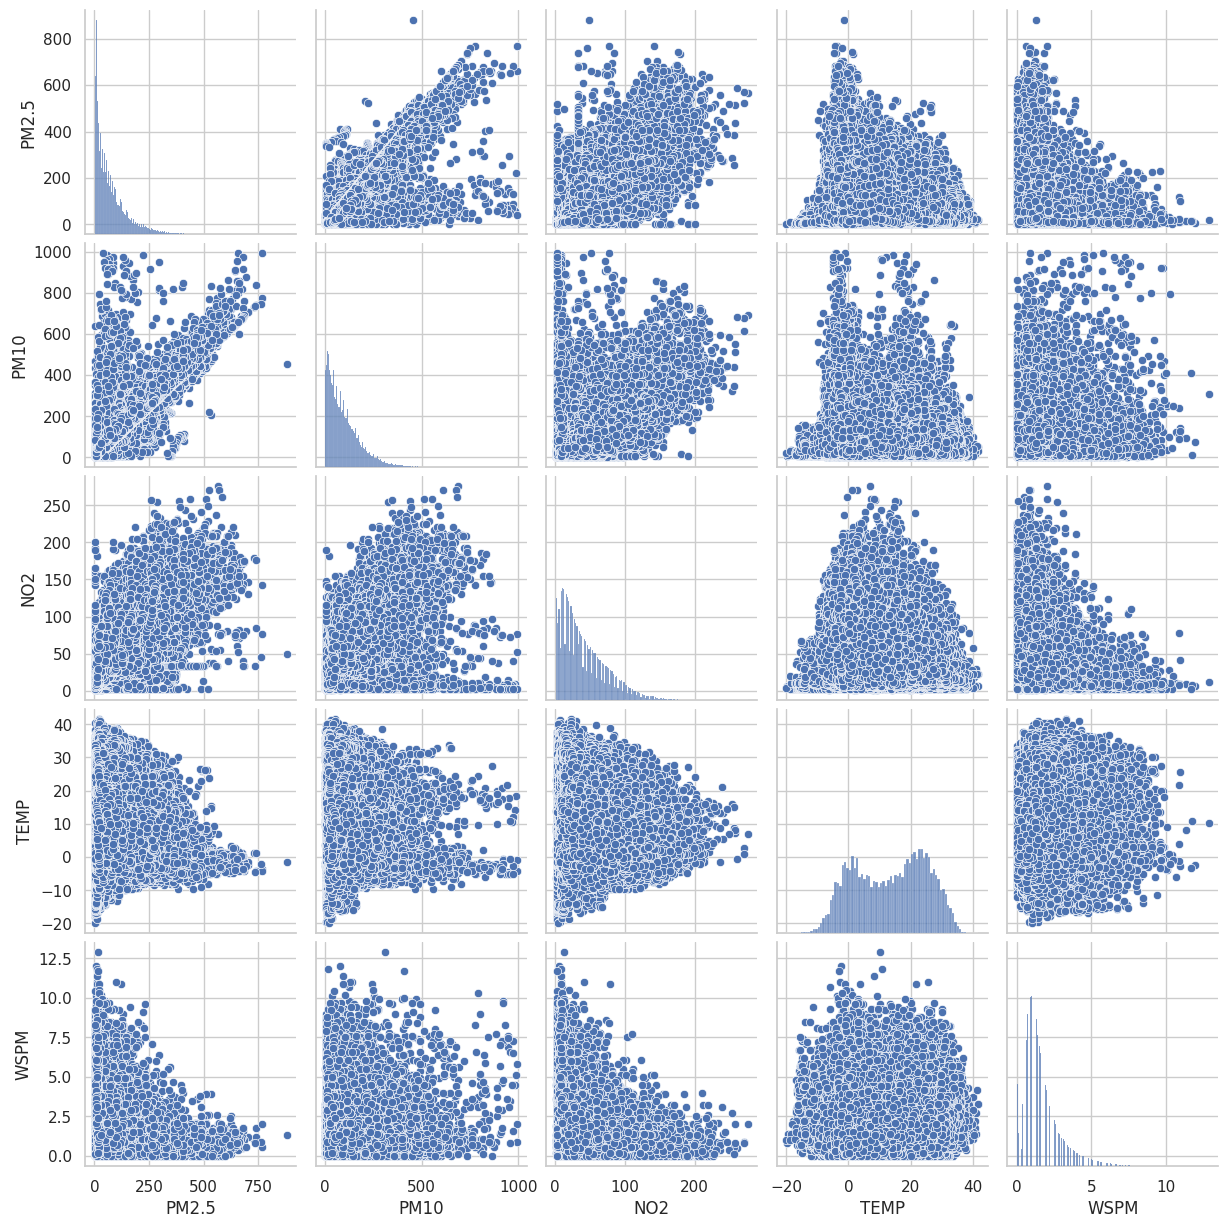

In [19]:
sns.pairplot(df[["PM2.5", "PM10", "NO2", "TEMP", "WSPM"]])

This pairplot confirms the patterns seen in the heatmap and shows the multiple relationships between each factors simultaneously.

**2.3.4 Station Comparison**

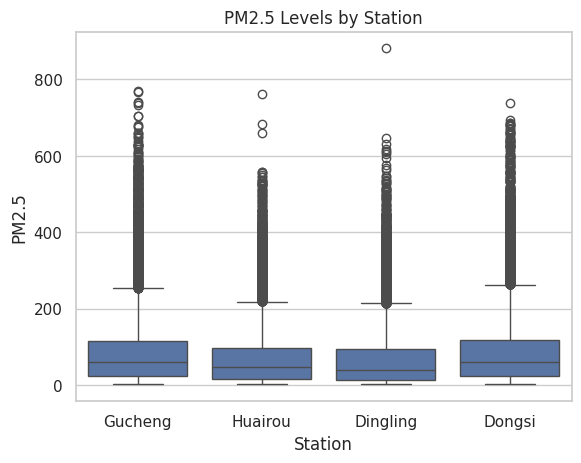

In [20]:
sns.boxplot(data=df, x="station", y="PM2.5")
plt.title("PM2.5 Levels by Station")
plt.xlabel("Station")
plt.ylabel("PM2.5")
plt.show()

This boxplot compares PM2.5 levels across the four selected stations, highlighting the difference between urban and suburban air quality. The blue boxes in the plot represent the typical pollution levels, with most of the stations sharing similar results. Despite this, there are a few outliers present, represented by the circles extending past 800. Furthermore, the urban places, Dongsi and Gucheng, tend to have slightly higher median pollution and more frequent spikes when compared to the suburban places, Dingling and Huariou.

**2.3.5 Temporal Analysis**

1. Monthly Trend

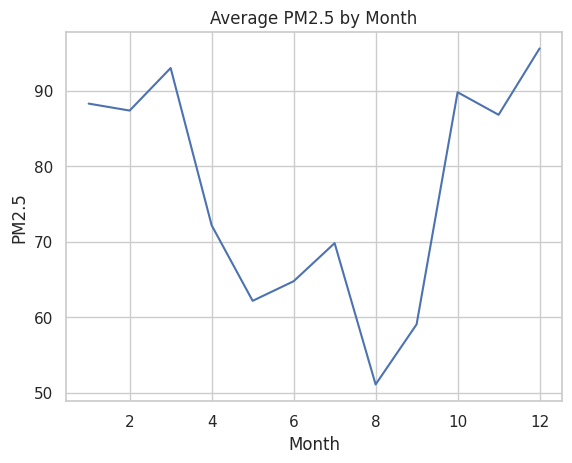

In [21]:
df.groupby("month_extracted")["PM2.5"].mean().plot()
plt.title("Average PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("PM2.5")
plt.show()

This line graph showcases the average PM2.5 levels across each month in the year, revealing a clear seasonal trend. Pollution levels appear to be highest during the winter period (October to March) and lowest during the summer, particularly around the 8th month (August). This observation suggests that colder temperatures contribute to increased pollution due to a combination of increased emissions and lower atmospheric dispersion.

2. Hourly Trend

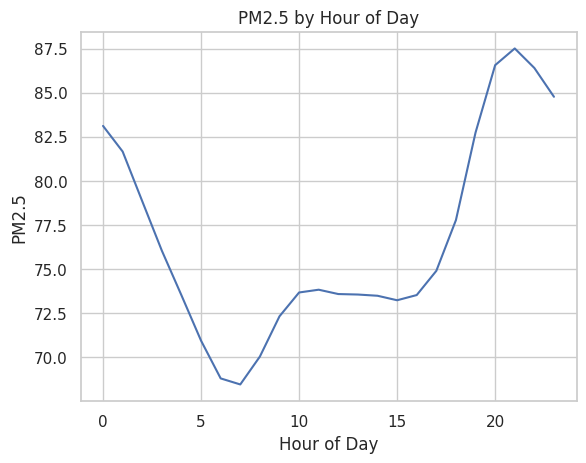

In [22]:
df.groupby("hour_extracted")["PM2.5"].mean().plot()
plt.title("PM2.5 by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("PM2.5")
plt.show()

This graph illustrates the variation of PM2.5 levels in an hourly rate throughout the day. Pollution levels are lowest in the early hours of the morning and increase significantly throughout the day into the evening, peaking between hours 20 and 22. This suggests that humans contribute towards higher pollution levels, whether that be through causing traffic jams or any other external factors.

**2.3 Summary**

*   PM2.5 and PM10 are strongly correlated, suggesting emission sources.
*  Urban stations exhibit consistently higher pollution levels in comparison with suburban stations
*   Wind speeds negatively impacts pollution levels, indicating its role in successfully dispersing pollutants in the air.
*   Seasonal trends show increased pollution levels during winter months, likely due increased heating and atmospheric conditions.
*   The increase in PM2.5 during winter coincides with lower temperatures and reduced wind speeds, suggesting that both conditions contribute to higher pollution levels.
*   Finally, the wide range of wind directions throughout the dataset suggests that the high pollution levels are not just local, but are also heavily influenced by the direction of incoming air flow from the surrounding regions.






# Task 3: Model Building

**Justification for Machine-Learning Model**

**3.1 Model Design and Preparation**

**3.2 Model Implementation**

**3.3 Model Evaluation**

**3.4 Model Insights**